In [2]:
import ac3airborne

import os

# local caching
try:
    from dotenv import load_dotenv

    load_dotenv()

    local_storage = os.environ['INTAKE_CACHE']
except ImportError:
    local_storage = '/tmp/'

kwds = {'simplecache': dict(
    cache_storage=local_storage, 
    same_names=True
)}

cat = ac3airborne.get_intake_catalog()

In [3]:
flight_id = 'COMPEX_P5_RF11'
campaign, platform, rf = flight_id.split('_')

In [9]:
ds_sic = cat[campaign][platform]['AMSR2_SIC'][flight_id].to_dask()

/net/sever/mech/miniconda3/envs/howtoac3/lib/python3.11/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np


Text(0, 0.5, 'Time (hh:mm) [UTC]')

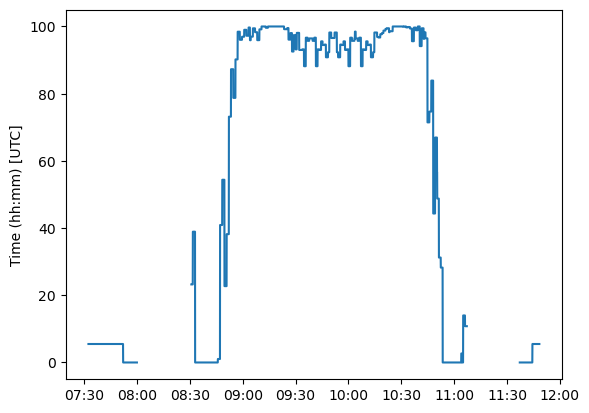

In [ ]:
fig, ax = plt.subplots(1, 1, sharex=True)

ax.plot(ds_sic.time,ds_sic.sic/100.)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Time (hh:mm) [UTC]')


In [ ]:
fig, ax = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=10)))
                
ax.coastlines(color='white')
ax.set_facecolor('k')
        
im = ax.scatter(ds_sic.lon, ds_sic.lat, c=ds_sic.sic, vmin=0, vmax=100, transform=ccrs.PlateCarree(), cmap='Blues_r', s=1, lw=0)
ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=["left", "bottom"],
    xlocs=mticker.FixedLocator(np.arange(-10, 20, 1)),
    ylocs=mticker.FixedLocator(np.arange(75, 85, 1)),
    x_inline=False,
    y_inline=False,
    rotate_labels=False,
    linewidth=0.25,
    color="#1F7298",
    alpha=0.5,
    zorder=5,
)

fig.colorbar(im, ax=ax, label="Sea ice concentration [%]")


NameError: name 'plt' is not defined